In [1]:
import pandas as pd
df = pd.read_csv('agriculture_yield_dataset.csv')
print(df.shape)
print(df.columns.tolist())
df.head(10)

(1500, 8)
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [2]:
df.dtypes
df.isnull().sum()

,0
rainfall_mm,0
temperature_c,0
fertilizer_kg,0
irrigation_hours,0
soil_ph,0
crop_type,0
soil_type,0
yield_ton_per_hectare,0


In [3]:
df.describe()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


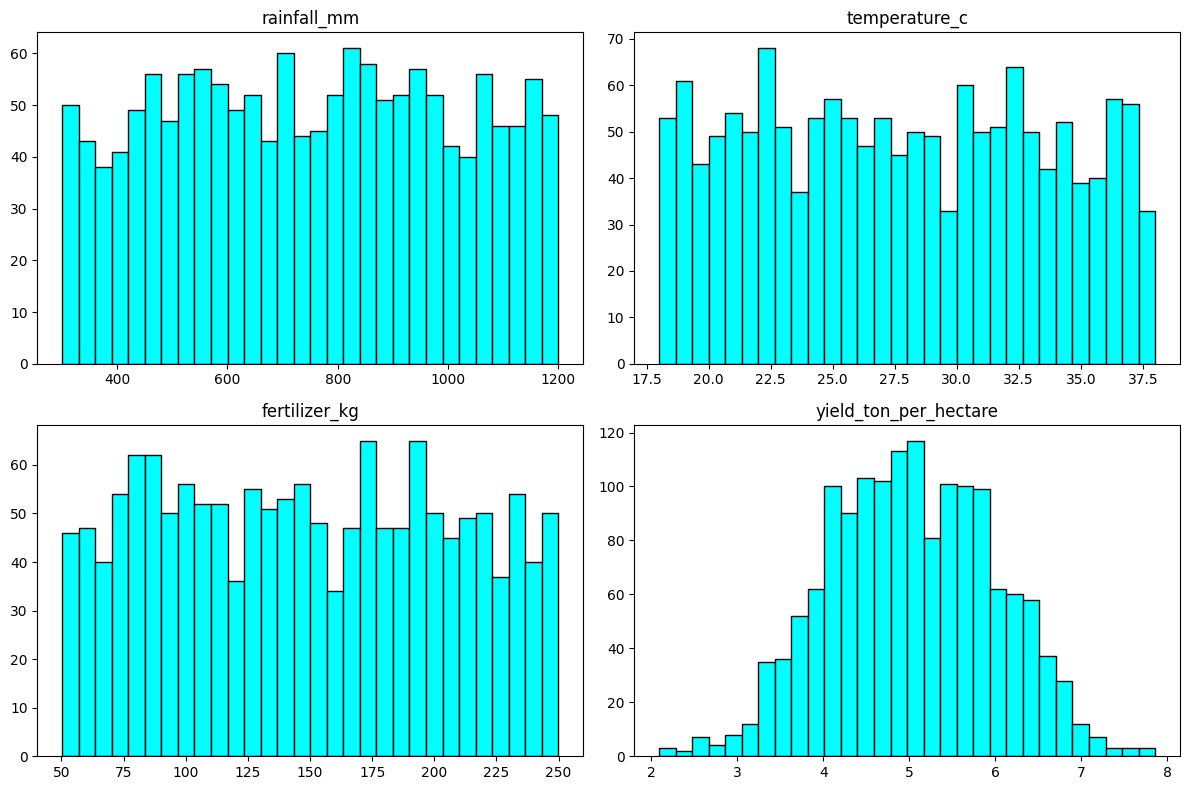

In [9]:
import matplotlib.pyplot as plt

cols = ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'yield_ton_per_hectare']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), cols):
    ax.hist(df[col], bins=30, color='cyan', edgecolor='black')
    ax.set_title(col)
plt.tight_layout()
plt.show()

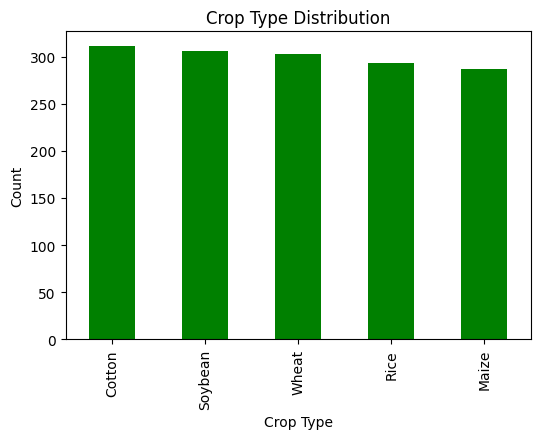

In [8]:
df['crop_type'].value_counts()

plt.figure(figsize=(6,4))
df['crop_type'].value_counts().plot(kind='bar', color='green')
plt.title('Crop Type Distribution')
plt.xlabel('Crop Type'); plt.ylabel('Count')
plt.show()

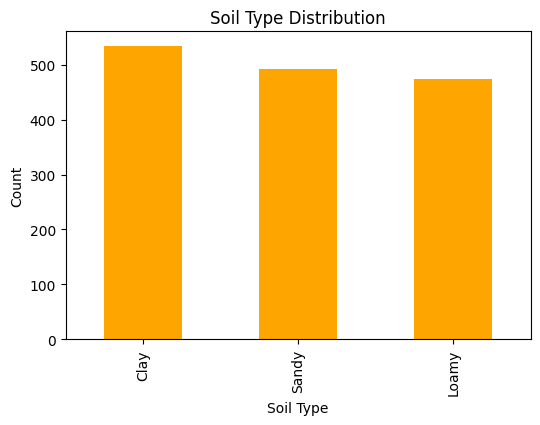

In [7]:
df['soil_type'].value_counts()

plt.figure(figsize=(6,4))
df['soil_type'].value_counts().plot(kind='bar', color='orange')
plt.title('Soil Type Distribution')
plt.xlabel('Soil Type'); plt.ylabel('Count')
plt.show()

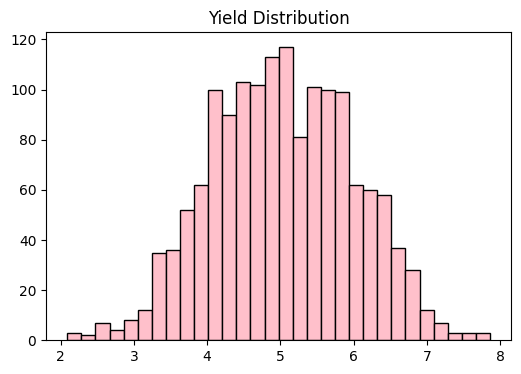

In [13]:
plt.figure(figsize=(6,4))
plt.hist(df['yield_ton_per_hectare'], bins=30, color='pink', edgecolor='black')
plt.title('Yield Distribution')
plt.show()

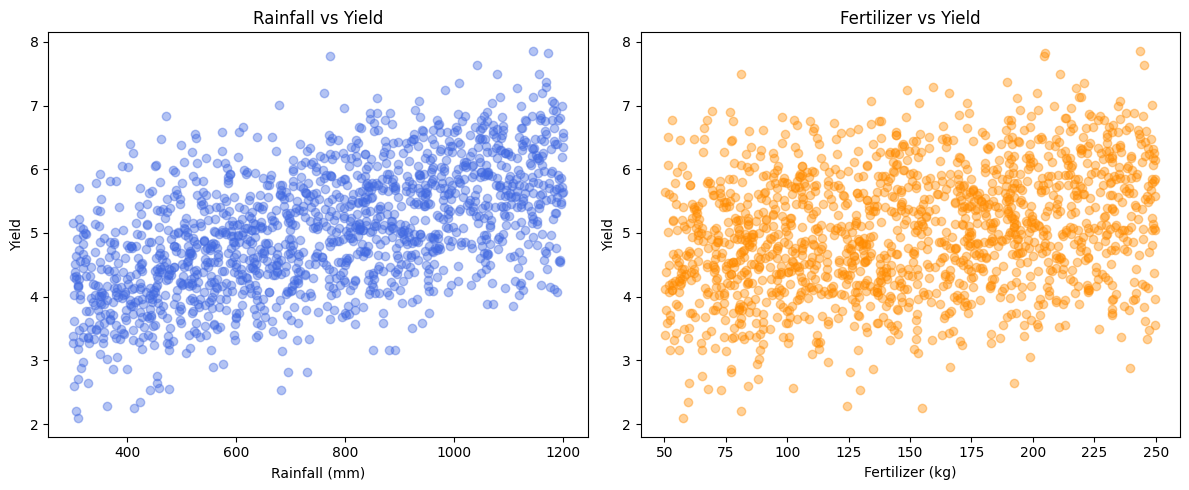

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].scatter(df['rainfall_mm'], df['yield_ton_per_hectare'], alpha=0.4, color='royalblue')
axes[0].set_xlabel('Rainfall (mm)'); axes[0].set_ylabel('Yield')
axes[0].set_title('Rainfall vs Yield')

axes[1].scatter(df['fertilizer_kg'], df['yield_ton_per_hectare'], alpha=0.4, color='darkorange')
axes[1].set_xlabel('Fertilizer (kg)'); axes[1].set_ylabel('Yield')
axes[1].set_title('Fertilizer vs Yield')
plt.tight_layout()
plt.show()

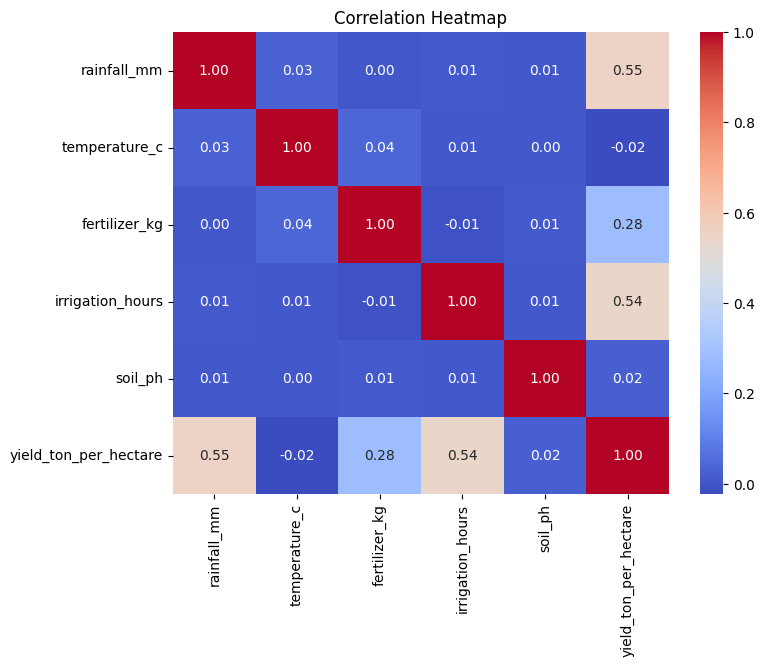

,yield_ton_per_hectare
yield_ton_per_hectare,1.000000
rainfall_mm,0.553704
irrigation_hours,0.542664
fertilizer_kg,0.278043
soil_ph,0.024412
temperature_c,-0.022559


In [15]:
import seaborn as sns

corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

corr_matrix['yield_ton_per_hectare'].sort_values(ascending=False)


In [16]:
df.groupby('crop_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
df.groupby('soil_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)

,yield_ton_per_hectare
soil_type,
Loamy,5.366519
Clay,5.134326
Sandy,4.588882


In [17]:
df_encoded = pd.get_dummies(df, columns=['crop_type', 'soil_type'], drop_first=True)
df_encoded.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [21]:
X = df_encoded.drop('yield_ton_per_hectare', axis=1)
y = df_encoded['yield_ton_per_hectare']
print(X,y)

      rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0           588.6           18.6          242.4               6.5      6.5   
1           772.8           34.6          247.2              10.0      6.5   
2           970.9           36.3          168.4               7.3      6.4   
3           611.7           19.0          121.7               3.7      6.0   
4           696.1           29.6          184.6               5.1      6.1   
...           ...            ...            ...               ...      ...   
1495        473.8           32.3           65.0               3.6      5.8   
1496        825.9           18.4          200.8               9.9      6.7   
1497        329.3           23.3           90.3               7.7      7.0   
1498        801.7           28.6          204.1               3.4      6.9   
1499        684.8           23.7           88.9               1.2      5.9   

      crop_type_Maize  crop_type_Rice  crop_type_Soybean  crop_

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1200, 11)
X_test: (300, 11)
y_train: (1200,)
y_test: (300,)


In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
coefficients = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
print(coefficients)

Intercept: 1.587132027736121
crop_type_Rice       0.863993
crop_type_Soybean    0.481719
crop_type_Wheat      0.348474
soil_type_Loamy      0.302974
crop_type_Maize      0.238931
irrigation_hours     0.198327
fertilizer_kg        0.004978
soil_ph              0.004901
rainfall_mm          0.002035
temperature_c       -0.009175
soil_type_Sandy     -0.490933
dtype: float64
